# Classic Multi-Label Classifiers POC (HealthPH-style)

This notebook uses the same **traditional multi-label classifier family** used in the old HealthPH project:
- Binary Relevance + Logistic Regression
- Binary Relevance + SGD (log_loss)
- Classifier Chains + Logistic Regression
- Classifier Chains + SGD (log_loss)

Target labels (fixed order): `AURI, PN, TB, COVID`.


In [1]:
# Imports
import ast
import importlib.util
import json
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.sparse import hstack

# Ensure plotting libs are available inside notebook runtime
if importlib.util.find_spec('matplotlib') is None or importlib.util.find_spec('seaborn') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib', 'seaborn'])

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import f1_score, hamming_loss, multilabel_confusion_matrix, precision_recall_fscore_support
from sklearn.multioutput import ClassifierChain
from sklearn.multiclass import OneVsRestClassifier

# Ensure optuna is available inside notebook runtime
if importlib.util.find_spec('optuna') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna'])

import optuna
from optuna.samplers import TPESampler

sns.set_theme(style='whitegrid')


In [2]:
# Config
SEED = 42
TEST_SIZE = 0.10
VAL_SIZE = 0.10
LABELS = ["AURI", "PN", "TB", "COVID"]

# Optuna tuning config
N_TRIALS = 20
OPTUNA_TIMEOUT_SECONDS = None  # e.g. 1800 for 30 min cap

CWD = Path.cwd()
ROOT_DIR = next((p for p in [CWD, *CWD.parents] if (p / '.git').exists()), CWD)

DATA_CANDIDATES = [
    ROOT_DIR / 'Old Model/data/DATASET USED IN MODELS/Merged_dataset.csv',
    ROOT_DIR / 'Old Model/models/codes/Merged_dataset.csv',
]

DATA_PATH = next((p.resolve() for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    tried = '\n'.join(str(p) for p in DATA_CANDIDATES)
    raise FileNotFoundError(f'Could not locate Merged_dataset.csv from cwd={CWD}. Tried:\n{tried}')

OUTPUT_DIR = ROOT_DIR / 'reports' / 'classic_multilabel'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print({
    'cwd': str(CWD),
    'root_dir': str(ROOT_DIR),
    'DATA_PATH': str(DATA_PATH),
    'OUTPUT_DIR': str(OUTPUT_DIR),
    'N_TRIALS': N_TRIALS,
    'OPTUNA_TIMEOUT_SECONDS': OPTUNA_TIMEOUT_SECONDS,
})


{'cwd': '/Users/angelodelapaz/Documents/GitHub/healthphpersonal/notebooks', 'root_dir': '/Users/angelodelapaz/Documents/GitHub/healthphpersonal', 'DATA_PATH': '/Users/angelodelapaz/Documents/GitHub/healthphpersonal/Old Model/data/DATASET USED IN MODELS/Merged_dataset.csv', 'OUTPUT_DIR': '/Users/angelodelapaz/Documents/GitHub/healthphpersonal/reports/classic_multilabel', 'N_TRIALS': 20, 'OPTUNA_TIMEOUT_SECONDS': None}


In [3]:
# Data loading + validation
raw_df = pd.read_csv(DATA_PATH)


def parse_label_vector(value, expected_len=4):
    parsed = ast.literal_eval(str(value))
    if not isinstance(parsed, (list, tuple)):
        raise ValueError('annotate must parse to list/tuple')
    if len(parsed) != expected_len:
        raise ValueError(f'annotate length must be {expected_len}')
    out = []
    for item in parsed:
        if item not in (0, 1):
            raise ValueError('annotate values must be 0/1')
        out.append(int(item))
    return out


rows = []
for _, row in raw_df.iterrows():
    post = row.get('post')
    annotate = row.get('annotate')

    if not isinstance(post, str) or not post.strip():
        continue

    try:
        y = parse_label_vector(annotate, expected_len=len(LABELS))
    except Exception:
        continue

    rows.append({
        'post': ' '.join(post.split()),
        'annotate': str(y),
        **{label: y[i] for i, label in enumerate(LABELS)},
    })

clean_df = pd.DataFrame(rows).drop_duplicates(subset=['post']).reset_index(drop=True)
print('raw_rows=', len(raw_df), 'clean_rows=', len(clean_df))
print('label_counts=', clean_df[LABELS].sum().to_dict())


raw_rows= 21968 clean_rows= 6290
label_counts= {'AURI': 1272, 'PN': 859, 'TB': 953, 'COVID': 1285}


In [4]:
# Iterative multilabel split (dependency-free)
def iterative_multilabel_split_indices(y, test_size=0.1, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y, dtype=int)

    n_samples, n_labels = y.shape
    n_test = int(round(n_samples * test_size))
    n_test = max(1, min(n_samples - 1, n_test))

    all_idx = np.arange(n_samples)
    unassigned = set(all_idx.tolist())
    test_idx = []

    target = y.sum(axis=0) * test_size
    current = np.zeros(n_labels, dtype=float)
    cardinality = y.sum(axis=1)

    while len(test_idx) < n_test and unassigned:
        deficits = np.where(target - current > 0, target - current, 0)

        if deficits.sum() == 0:
            rem = np.array(list(unassigned))
            rng.shuffle(rem)
            test_idx.extend(rem[: (n_test - len(test_idx))].tolist())
            break

        chosen = None
        for label in np.argsort(-deficits):
            candidates = [i for i in unassigned if y[i, label] == 1]
            if not candidates:
                continue
            min_card = min(cardinality[candidates])
            filtered = [i for i in candidates if cardinality[i] == min_card]
            chosen = int(rng.choice(filtered))
            break

        if chosen is None:
            chosen = int(rng.choice(np.array(list(unassigned))))

        test_idx.append(chosen)
        unassigned.remove(chosen)
        current += y[chosen]

    test_idx = np.array(sorted(set(test_idx)))
    train_idx = np.array(sorted(list(set(all_idx) - set(test_idx))))
    return train_idx, test_idx


y_all = clean_df[LABELS].values
trainval_idx, test_idx = iterative_multilabel_split_indices(y_all, test_size=TEST_SIZE, random_state=SEED)
trainval_df = clean_df.iloc[trainval_idx].reset_index(drop=True)
test_df = clean_df.iloc[test_idx].reset_index(drop=True)

val_rel = VAL_SIZE / (1.0 - TEST_SIZE)
train_idx_local, val_idx_local = iterative_multilabel_split_indices(
    trainval_df[LABELS].values,
    test_size=val_rel,
    random_state=SEED,
)

train_df = trainval_df.iloc[train_idx_local].reset_index(drop=True)
val_df = trainval_df.iloc[val_idx_local].reset_index(drop=True)

print('train=', len(train_df), 'val=', len(val_df), 'test=', len(test_df))


train= 5032 val= 629 test= 629


In [5]:
# TF-IDF feature pipeline
word_vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=2, max_features=100_000)
char_vec = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), min_df=2, max_features=100_000)

X_train = hstack([word_vec.fit_transform(train_df['post']), char_vec.fit_transform(train_df['post'])])
X_val = hstack([word_vec.transform(val_df['post']), char_vec.transform(val_df['post'])])
X_test = hstack([word_vec.transform(test_df['post']), char_vec.transform(test_df['post'])])

y_train = train_df[LABELS].values.astype(int)
y_val = val_df[LABELS].values.astype(int)
y_test = test_df[LABELS].values.astype(int)

print('X_train_shape=', X_train.shape)


X_train_shape= (5032, 134658)


In [6]:
# Helpers: probability extraction, threshold tuning, evaluation
def predict_proba_matrix(model, X):
    raw = model.predict_proba(X) if hasattr(model, 'predict_proba') else None

    if isinstance(raw, list):
        cols = []
        for arr in raw:
            arr = np.asarray(arr)
            if arr.ndim == 1:
                cols.append(arr)
            elif arr.ndim == 2 and arr.shape[1] >= 2:
                cols.append(arr[:, 1])
            elif arr.ndim == 2 and arr.shape[1] == 1:
                cols.append(arr[:, 0])
            else:
                raise ValueError(f'Unsupported per-label proba shape: {arr.shape}')
        return np.column_stack(cols)

    if raw is not None:
        raw = np.asarray(raw)
        if raw.ndim == 2:
            return raw
        if raw.ndim == 3 and raw.shape[2] >= 2:
            return raw[:, :, 1]

    if hasattr(model, 'decision_function'):
        d = np.asarray(model.decision_function(X))
        return 1 / (1 + np.exp(-d))

    raise RuntimeError('Model has no predict_proba/decision_function')


def tune_thresholds(y_true, y_proba, labels):
    thresholds = {}
    grid = np.arange(0.10, 0.901, 0.01)

    for i, label in enumerate(labels):
        best_t = 0.5
        best_f1 = -1.0
        for t in grid:
            pred = (y_proba[:, i] >= t).astype(int)
            _, _, f1, _ = precision_recall_fscore_support(
                y_true[:, i], pred, average='binary', zero_division=0
            )
            if f1 > best_f1:
                best_f1 = float(f1)
                best_t = float(np.round(t, 4))
        thresholds[label] = best_t

    return thresholds


def apply_thresholds(y_proba, thresholds, labels):
    y_pred = np.zeros_like(y_proba, dtype=int)
    for i, label in enumerate(labels):
        y_pred[:, i] = (y_proba[:, i] >= thresholds[label]).astype(int)
    return y_pred


def evaluate(y_true, y_pred, labels):
    summary = {
        'micro_f1': float(f1_score(y_true, y_pred, average='micro', zero_division=0)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'hamming_loss': float(hamming_loss(y_true, y_pred)),
        'exact_match_ratio': float(np.mean(np.all(y_true == y_pred, axis=1))),
    }

    per_label_rows = []
    for i, label in enumerate(labels):
        p, r, f1, _ = precision_recall_fscore_support(
            y_true[:, i], y_pred[:, i], average='binary', zero_division=0
        )
        per_label_rows.append({'label': label, 'precision': float(p), 'recall': float(r), 'f1': float(f1)})

    mcm = multilabel_confusion_matrix(y_true, y_pred)
    cm_rows = []
    for i, label in enumerate(labels):
        tn, fp, fn, tp = mcm[i].ravel()
        cm_rows.append({'label': label, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})

    return summary, pd.DataFrame(per_label_rows), pd.DataFrame(cm_rows)


In [7]:
# Model definitions + builders (HealthPH classic approach)
MODEL_FAMILIES = [
    'BinaryRelevance_LogReg',
    'BinaryRelevance_SGD',
    'ClassifierChains_LogReg',
    'ClassifierChains_SGD',
]


def build_model(model_name, params, seed=SEED):
    if model_name == 'BinaryRelevance_LogReg':
        base = LogisticRegression(
            class_weight='balanced',
            solver='saga',
            C=float(params['C']),
            max_iter=int(params['max_iter']),
            random_state=seed,
        )
        return OneVsRestClassifier(base)

    if model_name == 'BinaryRelevance_SGD':
        base = SGDClassifier(
            loss='log_loss',
            alpha=float(params['alpha']),
            penalty=str(params['penalty']),
            class_weight='balanced',
            max_iter=int(params['max_iter']),
            random_state=seed,
        )
        return OneVsRestClassifier(base)

    if model_name == 'ClassifierChains_LogReg':
        base = LogisticRegression(
            class_weight='balanced',
            solver='saga',
            C=float(params['C']),
            max_iter=int(params['max_iter']),
            random_state=seed,
        )
        return ClassifierChain(base, order='random', random_state=seed)

    if model_name == 'ClassifierChains_SGD':
        base = SGDClassifier(
            loss='log_loss',
            alpha=float(params['alpha']),
            penalty=str(params['penalty']),
            class_weight='balanced',
            max_iter=int(params['max_iter']),
            random_state=seed,
        )
        return ClassifierChain(base, order='random', random_state=seed)

    raise ValueError(f'Unknown model_name: {model_name}')


def suggest_params(trial, model_name):
    if 'LogReg' in model_name:
        return {
            'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
            'max_iter': trial.suggest_int('max_iter', 800, 2500, step=100),
        }

    # SGD search space
    return {
        'alpha': trial.suggest_float('alpha', 1e-6, 1e-2, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        'max_iter': trial.suggest_int('max_iter', 1000, 3000, step=250),
    }


MODEL_FAMILIES


['BinaryRelevance_LogReg',
 'BinaryRelevance_SGD',
 'ClassifierChains_LogReg',
 'ClassifierChains_SGD']

In [8]:
# Optuna tuning + train + expanded outputs
summary_rows = []
best_params_by_model = {}


def labels_from_binary_row(row, labels):
    return [label for i, label in enumerate(labels) if int(row[i]) == 1]


for model_name in MODEL_FAMILIES:
    print(f'\n===== {model_name} =====')

    def objective(trial):
        params = suggest_params(trial, model_name)
        model = build_model(model_name, params, seed=SEED)
        model.fit(X_train, y_train)

        val_proba = predict_proba_matrix(model, X_val)
        thresholds = tune_thresholds(y_val, val_proba, LABELS)
        y_val_pred = apply_thresholds(val_proba, thresholds, LABELS)

        # Optimize for validation micro-F1
        score = f1_score(y_val, y_val_pred, average='micro', zero_division=0)
        return float(score)

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=SEED),
        study_name=model_name,
    )
    study.optimize(objective, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT_SECONDS)

    best_params = study.best_params
    best_val_score = float(study.best_value)
    print('Best val micro_f1:', round(best_val_score, 4))
    print('Best params:', best_params)

    # Train final model with best params
    model = build_model(model_name, best_params, seed=SEED)
    model.fit(X_train, y_train)

    # Validation outputs
    val_proba = predict_proba_matrix(model, X_val)
    thresholds = tune_thresholds(y_val, val_proba, LABELS)
    y_val_pred = apply_thresholds(val_proba, thresholds, LABELS)
    val_summary, val_per_label_df, val_confusion_df = evaluate(y_val, y_val_pred, LABELS)

    # Test outputs
    test_proba = predict_proba_matrix(model, X_test)
    y_test_pred = apply_thresholds(test_proba, thresholds, LABELS)
    test_summary, test_per_label_df, test_confusion_df = evaluate(y_test, y_test_pred, LABELS)

    # Expanded result row
    summary_rows.append({
        'model': model_name,
        'optuna_best_val_micro_f1': best_val_score,
        'val_micro_f1': val_summary['micro_f1'],
        'val_macro_f1': val_summary['macro_f1'],
        'val_hamming_loss': val_summary['hamming_loss'],
        'val_exact_match_ratio': val_summary['exact_match_ratio'],
        'test_micro_f1': test_summary['micro_f1'],
        'test_macro_f1': test_summary['macro_f1'],
        'test_hamming_loss': test_summary['hamming_loss'],
        'test_exact_match_ratio': test_summary['exact_match_ratio'],
        'n_trials': len(study.trials),
    })

    # Save per-label metrics (val + test)
    val_per_label_df = val_per_label_df.copy()
    val_per_label_df.insert(0, 'split', 'val')
    val_per_label_df.insert(0, 'model', model_name)

    test_per_label_df = test_per_label_df.copy()
    test_per_label_df.insert(0, 'split', 'test')
    test_per_label_df.insert(0, 'model', model_name)

    pd.concat([val_per_label_df, test_per_label_df], ignore_index=True).to_csv(
        OUTPUT_DIR / f'{model_name}_per_label_metrics.csv',
        index=False,
    )

    # Save confusion matrices (val + test)
    val_confusion_df = val_confusion_df.copy()
    val_confusion_df.insert(0, 'split', 'val')
    val_confusion_df.insert(0, 'model', model_name)

    test_confusion_df = test_confusion_df.copy()
    test_confusion_df.insert(0, 'split', 'test')
    test_confusion_df.insert(0, 'model', model_name)

    pd.concat([val_confusion_df, test_confusion_df], ignore_index=True).to_csv(
        OUTPUT_DIR / f'{model_name}_confusion_matrix.csv',
        index=False,
    )

    # Save thresholds + params + trials
    with open(OUTPUT_DIR / f'{model_name}_thresholds.json', 'w', encoding='utf-8') as f:
        json.dump(thresholds, f, indent=2)

    with open(OUTPUT_DIR / f'{model_name}_best_params.json', 'w', encoding='utf-8') as f:
        json.dump(best_params, f, indent=2)

    best_params_by_model[model_name] = {
        'best_params': best_params,
        'best_val_micro_f1': best_val_score,
        'n_trials': len(study.trials),
    }

    study.trials_dataframe().to_csv(OUTPUT_DIR / f'{model_name}_optuna_trials.csv', index=False)

    # Save detailed test predictions
    pred_df = pd.DataFrame({
        'post': test_df['post'].tolist(),
    })

    for i, label in enumerate(LABELS):
        pred_df[f'true_{label}'] = y_test[:, i]
        pred_df[f'pred_{label}'] = y_test_pred[:, i]
        pred_df[f'proba_{label}'] = test_proba[:, i]

    pred_df['true_labels'] = [
        ','.join(labels_from_binary_row(row, LABELS)) if np.sum(row) > 0 else 'NONE'
        for row in y_test
    ]
    pred_df['pred_labels'] = [
        ','.join(labels_from_binary_row(row, LABELS)) if np.sum(row) > 0 else 'NONE'
        for row in y_test_pred
    ]

    pred_df.to_csv(OUTPUT_DIR / f'{model_name}_test_predictions.csv', index=False)

    error_df = pred_df[pred_df['true_labels'] != pred_df['pred_labels']].copy()
    error_df.to_csv(OUTPUT_DIR / f'{model_name}_error_analysis.csv', index=False)

    print(model_name, 'test_micro_f1=', round(test_summary['micro_f1'], 4), 'test_macro_f1=', round(test_summary['macro_f1'], 4))


with open(OUTPUT_DIR / 'best_hyperparameters_by_model.json', 'w', encoding='utf-8') as f:
    json.dump(best_params_by_model, f, indent=2)

print('Saved consolidated best hyperparameters:', OUTPUT_DIR / 'best_hyperparameters_by_model.json')


[I 2026-04-07 10:10:06,336] A new study created in memory with name: BinaryRelevance_LogReg



===== BinaryRelevance_LogReg =====


[I 2026-04-07 10:10:08,177] Trial 0 finished with value: 0.6732533521524348 and parameters: {'C': 0.03148911647956861, 'max_iter': 2500}. Best is trial 0 with value: 0.6732533521524348.
/Users/angelodelapaz/Documents/GitHub/healthphpersonal/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-04-07 10:10:40,541] Trial 1 finished with value: 0.7233748271092669 and parameters: {'C': 0.847180141881998, 'max_iter': 1800}. Best is trial 1 with value: 0.7233748271092669.
[I 2026-04-07 10:10:41,995] Trial 2 finished with value: 0.6429070580013976 and parameters: {'C': 0.004207988669606638, 'max_iter': 1000}. Best is trial 1 with value: 0.7233748271092669.
[I 2026-04-07 10:10:43,520] Trial 3 finished with value: 0.6354515050167224 and parameters: {'C': 0.0017073967431528124, 'max_iter': 2300}. Best is trial 1 with value: 0.7233748271092669.
[I 2026-04-07 10:10:45,806] Tr

Best val micro_f1: 0.7269
Best params: {'C': 1.1363180493902583, 'max_iter': 1600}


/Users/angelodelapaz/Documents/GitHub/healthphpersonal/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-04-07 10:16:33,478] A new study created in memory with name: BinaryRelevance_SGD


...

Best val micro_f1: 0.7153
Best params: {'C': 1.0642919042160008, 'max_iter': 1900}


/Users/angelodelapaz/Documents/GitHub/healthphpersonal/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-04-07 10:23:18,758] A new study created in memory with name: ClassifierChains_SGD


ClassifierChains_LogReg test_micro_f1= 0.5195 test_macro_f1= 0.5142

===== ClassifierChains_SGD =====


[I 2026-04-07 10:23:19,459] Trial 0 finished with value: 0.6865671641791045 and parameters: {'alpha': 3.1489116479568635e-05, 'penalty': 'l2', 'max_iter': 1250}. Best is trial 0 with value: 0.6865671641791045.
[I 2026-04-07 10:23:20,826] Trial 1 finished with value: 0.6431718061674009 and parameters: {'alpha': 4.207053950287936e-06, 'penalty': 'l1', 'max_iter': 2500}. Best is trial 0 with value: 0.6865671641791045.
[I 2026-04-07 10:23:21,748] Trial 2 finished with value: 0.6376360808709176 and parameters: {'alpha': 1.2087541473056965e-06, 'penalty': 'l2', 'max_iter': 1250}. Best is trial 0 with value: 0.6865671641791045.
[I 2026-04-07 10:23:23,034] Trial 3 finished with value: 0.6426470588235295 and parameters: {'alpha': 5.415244119402541e-06, 'penalty': 'l1', 'max_iter': 1500}. Best is trial 0 with value: 0.6865671641791045.
[I 2026-04-07 10:23:24,098] Trial 4 finished with value: 0.7133243606998654 and parameters: {'alpha': 0.0002801635158716259, 'penalty': 'elasticnet', 'max_iter': 

Best val micro_f1: 0.7143
Best params: {'alpha': 0.00012452668108659282, 'penalty': 'elasticnet', 'max_iter': 2250}
ClassifierChains_SGD test_micro_f1= 0.5389 test_macro_f1= 0.5313
Saved consolidated best hyperparameters: /Users/angelodelapaz/Documents/GitHub/healthphpersonal/reports/classic_multilabel/best_hyperparameters_by_model.json


In [9]:
# Final summary table + expanded output guide
summary_df = pd.DataFrame(summary_rows).sort_values(by='test_micro_f1', ascending=False).reset_index(drop=True)
summary_df.to_csv(OUTPUT_DIR / 'multilabel_evaluation_summary.csv', index=False)

print('Saved outputs to', OUTPUT_DIR)
print('Generated files per model:')
print('- *_best_params.json')
print('- *_optuna_trials.csv')
print('- *_thresholds.json')
print('- *_per_label_metrics.csv (val + test)')
print('- *_confusion_matrix.csv (val + test)')
print('- *_test_predictions.csv')
print('- *_error_analysis.csv')
print('- multilabel_evaluation_summary.csv')

summary_df


Saved outputs to /Users/angelodelapaz/Documents/GitHub/healthphpersonal/reports/classic_multilabel
Generated files per model:
- *_best_params.json
- *_optuna_trials.csv
- *_thresholds.json
- *_per_label_metrics.csv (val + test)
- *_confusion_matrix.csv (val + test)
- *_test_predictions.csv
- *_error_analysis.csv
- multilabel_evaluation_summary.csv


,model,optuna_best_val_micro_f1,val_micro_f1,val_macro_f1,val_hamming_loss,val_exact_match_ratio,test_micro_f1,test_macro_f1,test_hamming_loss,test_exact_match_ratio,n_trials
0,ClassifierChains_SGD,0.714286,0.714286,0.709752,0.163752,0.661367,0.538874,0.531302,0.273450,0.414944,20
1,BinaryRelevance_SGD,0.725796,0.725796,0.719017,0.160970,0.669316,0.533775,0.521630,0.279809,0.395866,20
2,BinaryRelevance_LogReg,0.726908,0.726908,0.717975,0.162162,0.669316,0.522667,0.506403,0.284579,0.376789,20
3,ClassifierChains_LogReg,0.715308,0.715308,0.710721,0.158188,0.674086,0.519517,0.514166,0.269078,0.419714,20


## Results Analysis (Dynamic Graphs and Matrices)

This section is computed from files in `reports/classic_multilabel` each time you run it.
No metric values are hard-coded in markdown.

In [10]:
# Load analysis artifacts (dynamic)
analysis_dir = OUTPUT_DIR
summary_path = analysis_dir / 'multilabel_evaluation_summary.csv'

if not summary_path.exists():
    raise FileNotFoundError(
        f'{summary_path} not found. Run the model training/evaluation cells first.'
    )

summary_vis = pd.read_csv(summary_path).sort_values('test_micro_f1', ascending=False).reset_index(drop=True)
summary_vis['generalization_gap_micro_f1'] = summary_vis['val_micro_f1'] - summary_vis['test_micro_f1']

per_label_parts = []
confusion_parts = []
trials_parts = []
threshold_rows = []

for model_name in summary_vis['model']:
    per_label_path = analysis_dir / f'{model_name}_per_label_metrics.csv'
    confusion_path = analysis_dir / f'{model_name}_confusion_matrix.csv'
    trials_path = analysis_dir / f'{model_name}_optuna_trials.csv'
    thresholds_path = analysis_dir / f'{model_name}_thresholds.json'

    if per_label_path.exists():
        per_label_parts.append(pd.read_csv(per_label_path))
    if confusion_path.exists():
        confusion_parts.append(pd.read_csv(confusion_path))
    if trials_path.exists():
        tdf = pd.read_csv(trials_path)
        if 'model' not in tdf.columns:
            tdf['model'] = model_name
        trials_parts.append(tdf)
    if thresholds_path.exists():
        with open(thresholds_path, 'r', encoding='utf-8') as f:
            th = json.load(f)
        for label, value in th.items():
            threshold_rows.append({'model': model_name, 'label': label, 'threshold': float(value)})

per_label_df = pd.concat(per_label_parts, ignore_index=True) if per_label_parts else pd.DataFrame()
confusion_df = pd.concat(confusion_parts, ignore_index=True) if confusion_parts else pd.DataFrame()
trials_df = pd.concat(trials_parts, ignore_index=True) if trials_parts else pd.DataFrame()
threshold_df = pd.DataFrame(threshold_rows)

print('Loaded analysis artifacts from:', analysis_dir)
print('Summary rows:', len(summary_vis))
print('Per-label rows:', len(per_label_df))
print('Confusion rows:', len(confusion_df))
print('Optuna trials rows:', len(trials_df))
print('Threshold rows:', len(threshold_df))

summary_vis


Loaded analysis artifacts from: /Users/angelodelapaz/Documents/GitHub/healthphpersonal/reports/classic_multilabel
Summary rows: 4
Per-label rows: 32
Confusion rows: 32
Optuna trials rows: 80
Threshold rows: 16


,model,optuna_best_val_micro_f1,val_micro_f1,val_macro_f1,val_hamming_loss,val_exact_match_ratio,test_micro_f1,test_macro_f1,test_hamming_loss,test_exact_match_ratio,n_trials,generalization_gap_micro_f1
0,ClassifierChains_SGD,0.714286,0.714286,0.709752,0.163752,0.661367,0.538874,0.531302,0.273450,0.414944,20,0.175412
1,BinaryRelevance_SGD,0.725796,0.725796,0.719017,0.160970,0.669316,0.533775,0.521630,0.279809,0.395866,20,0.192021
2,BinaryRelevance_LogReg,0.726908,0.726908,0.717975,0.162162,0.669316,0.522667,0.506403,0.284579,0.376789,20,0.204241
3,ClassifierChains_LogReg,0.715308,0.715308,0.710721,0.158188,0.674086,0.519517,0.514166,0.269078,0.419714,20,0.195790


/var/folders/mq/j8mtkq590gl29rkr5th7fzdh0000gp/T/ipykernel_3680/1150852740.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


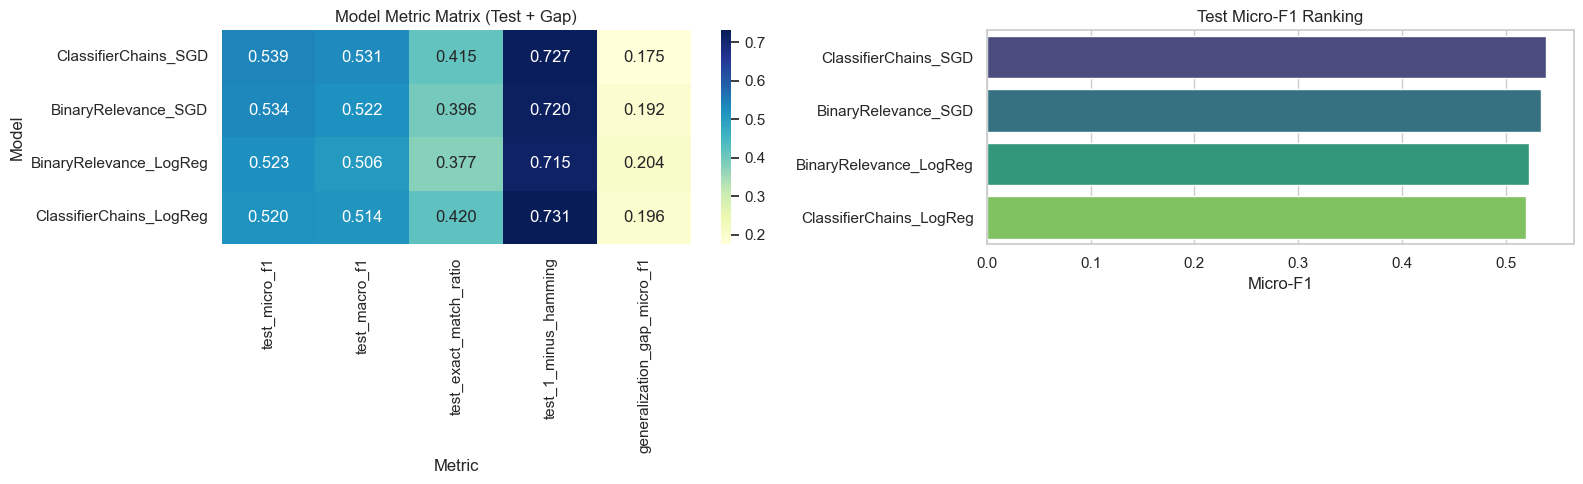

/var/folders/mq/j8mtkq590gl29rkr5th7fzdh0000gp/T/ipykernel_3680/1150852740.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


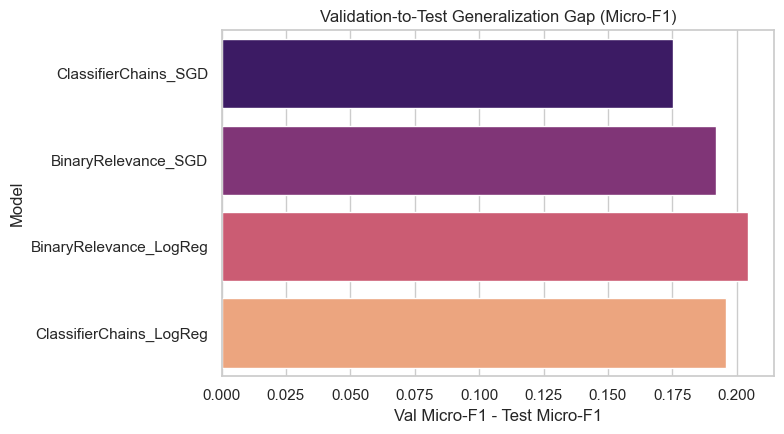

In [11]:
# Overall performance graphs/matrices
plot_df = summary_vis.copy()
plot_df['test_1_minus_hamming'] = 1.0 - plot_df['test_hamming_loss']

metric_cols = [
    'test_micro_f1',
    'test_macro_f1',
    'test_exact_match_ratio',
    'test_1_minus_hamming',
    'generalization_gap_micro_f1',
]

metric_matrix = plot_df.set_index('model')[metric_cols]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    metric_matrix,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    ax=axes[0],
)
axes[0].set_title('Model Metric Matrix (Test + Gap)')
axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Model')

sns.barplot(
    data=plot_df,
    y='model',
    x='test_micro_f1',
    orient='h',
    palette='viridis',
    ax=axes[1],
)
axes[1].set_title('Test Micro-F1 Ranking')
axes[1].set_xlabel('Micro-F1')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=plot_df,
    y='model',
    x='generalization_gap_micro_f1',
    orient='h',
    palette='magma',
    ax=ax,
)
ax.set_title('Validation-to-Test Generalization Gap (Micro-F1)')
ax.set_xlabel('Val Micro-F1 - Test Micro-F1')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()


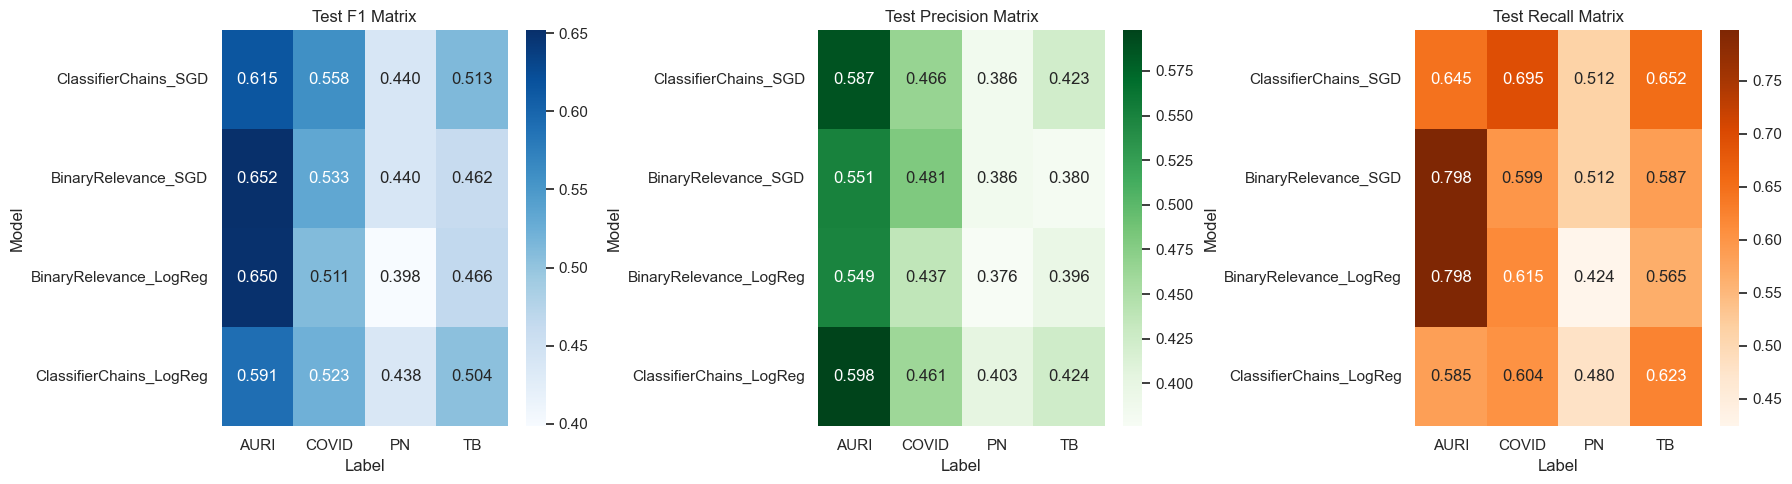

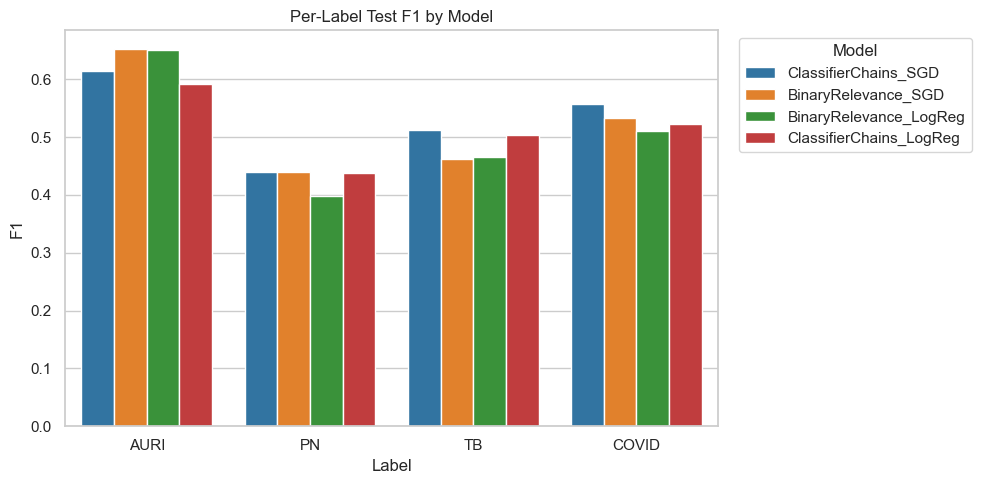

In [12]:
# Per-label performance matrices/graphs
if per_label_df.empty:
    raise ValueError('No per-label metrics found.')

test_per_label = per_label_df[per_label_df['split'] == 'test'].copy()

f1_matrix = test_per_label.pivot(index='model', columns='label', values='f1')
f1_matrix = f1_matrix.reindex(index=summary_vis['model'])

precision_matrix = test_per_label.pivot(index='model', columns='label', values='precision').reindex(index=summary_vis['model'])
recall_matrix = test_per_label.pivot(index='model', columns='label', values='recall').reindex(index=summary_vis['model'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(f1_matrix, annot=True, fmt='.3f', cmap='Blues', ax=axes[0])
axes[0].set_title('Test F1 Matrix')

sns.heatmap(precision_matrix, annot=True, fmt='.3f', cmap='Greens', ax=axes[1])
axes[1].set_title('Test Precision Matrix')

sns.heatmap(recall_matrix, annot=True, fmt='.3f', cmap='Oranges', ax=axes[2])
axes[2].set_title('Test Recall Matrix')

for ax in axes:
    ax.set_xlabel('Label')
    ax.set_ylabel('Model')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=test_per_label,
    x='label',
    y='f1',
    hue='model',
    palette='tab10',
    ax=ax,
)
ax.set_title('Per-Label Test F1 by Model')
ax.set_xlabel('Label')
ax.set_ylabel('F1')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


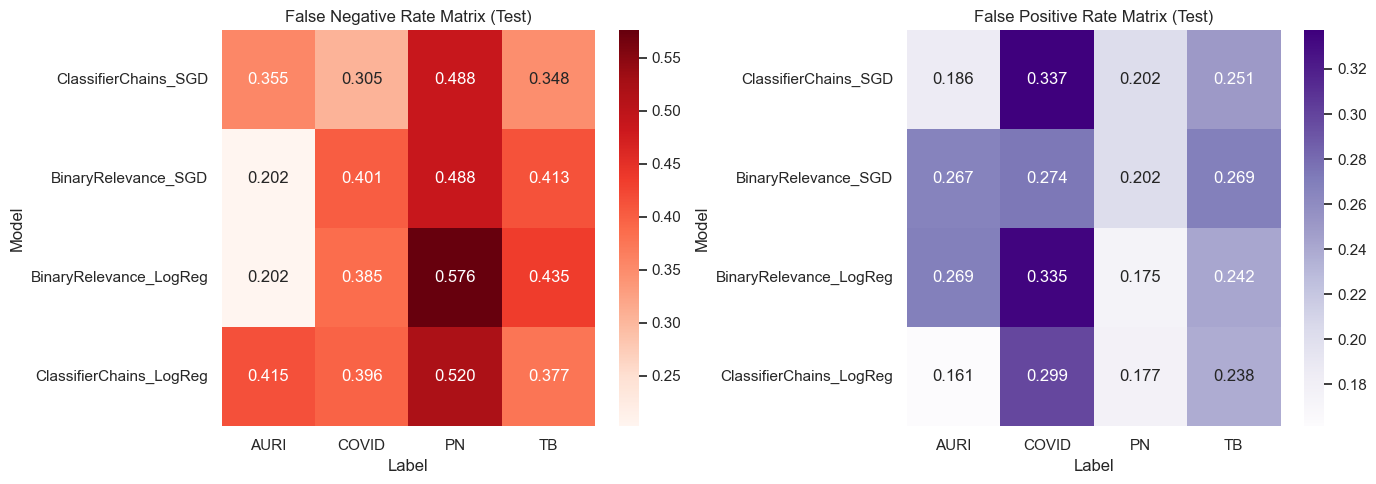

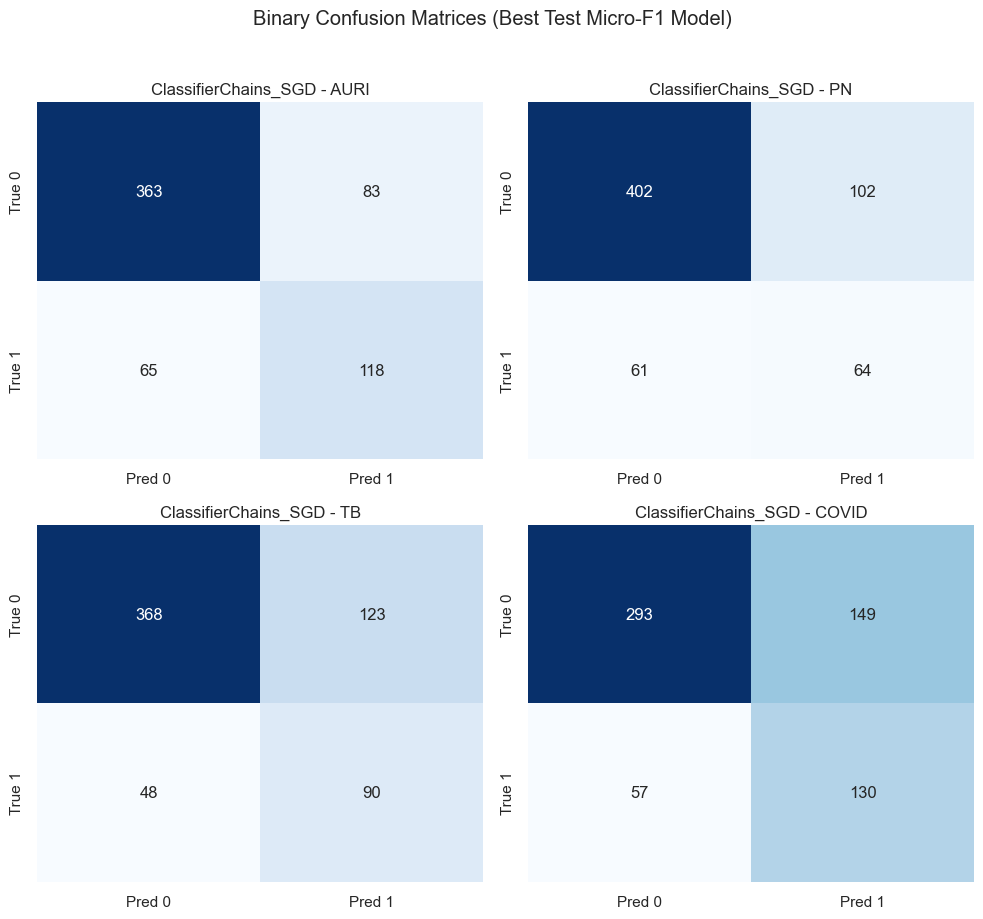

In [13]:
# Confusion-derived matrices + binary confusion matrices for best model
if confusion_df.empty:
    raise ValueError('No confusion matrix data found.')

test_conf = confusion_df[confusion_df['split'] == 'test'].copy()
test_conf['fn_rate'] = test_conf['fn'] / (test_conf['fn'] + test_conf['tp']).replace(0, np.nan)
test_conf['fp_rate'] = test_conf['fp'] / (test_conf['fp'] + test_conf['tn']).replace(0, np.nan)

fn_matrix = test_conf.pivot(index='model', columns='label', values='fn_rate').reindex(index=summary_vis['model'])
fp_matrix = test_conf.pivot(index='model', columns='label', values='fp_rate').reindex(index=summary_vis['model'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(fn_matrix, annot=True, fmt='.3f', cmap='Reds', ax=axes[0])
axes[0].set_title('False Negative Rate Matrix (Test)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Model')

sns.heatmap(fp_matrix, annot=True, fmt='.3f', cmap='Purples', ax=axes[1])
axes[1].set_title('False Positive Rate Matrix (Test)')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()

best_model = summary_vis.iloc[0]['model']
best_conf = test_conf[test_conf['model'] == best_model].copy()
label_order = [l for l in LABELS if l in best_conf['label'].tolist()]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()
for idx, label in enumerate(label_order):
    row = best_conf[best_conf['label'] == label].iloc[0]
    matrix = np.array([
        [row['tn'], row['fp']],
        [row['fn'], row['tp']],
    ])
    sns.heatmap(
        matrix,
        annot=True,
        fmt='.0f',
        cmap='Blues',
        cbar=False,
        ax=axes[idx],
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['True 0', 'True 1'],
    )
    axes[idx].set_title(f'{best_model} - {label}')

for j in range(len(label_order), 4):
    axes[j].axis('off')

plt.suptitle('Binary Confusion Matrices (Best Test Micro-F1 Model)', y=1.02)
plt.tight_layout()
plt.show()


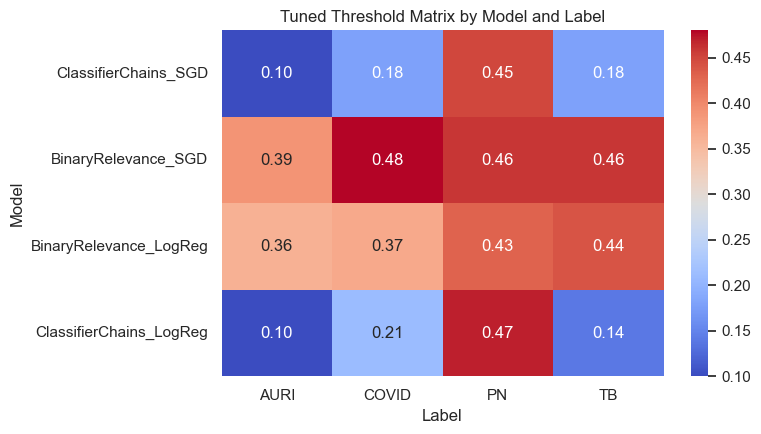

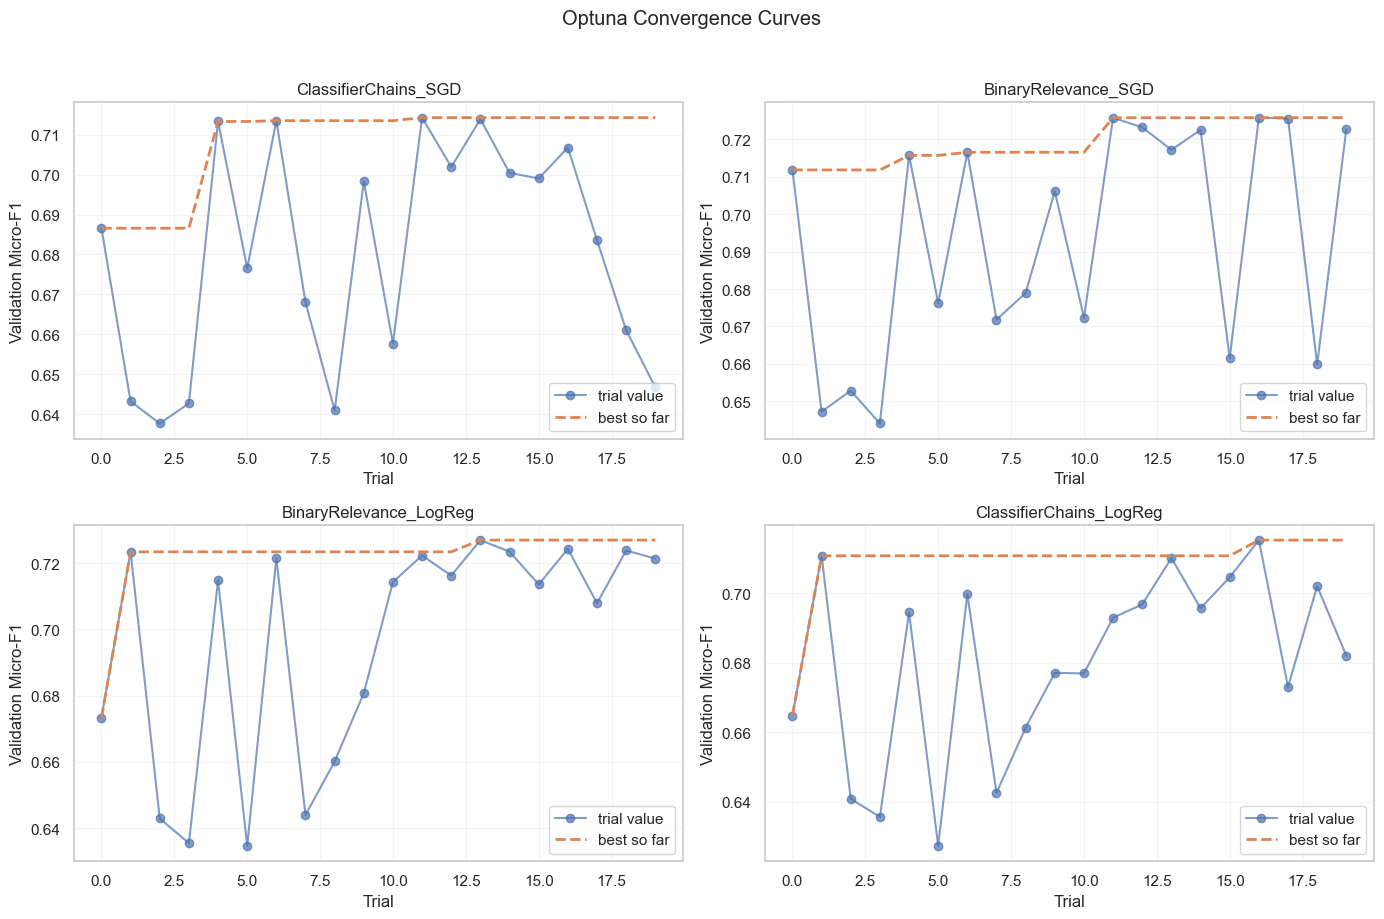

In [14]:
# Threshold matrix + Optuna search curves
if not threshold_df.empty:
    threshold_matrix = threshold_df.pivot(index='model', columns='label', values='threshold').reindex(index=summary_vis['model'])
    plt.figure(figsize=(8, 4.5))
    sns.heatmap(threshold_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Tuned Threshold Matrix by Model and Label')
    plt.xlabel('Label')
    plt.ylabel('Model')
    plt.tight_layout()
    plt.show()
else:
    print('No threshold files available for plotting.')

if not trials_df.empty:
    models = summary_vis['model'].tolist()
    n_models = len(models)
    n_cols = 2
    n_rows = int(np.ceil(n_models / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), squeeze=False)

    for idx, model_name in enumerate(models):
        r = idx // n_cols
        c = idx % n_cols
        ax = axes[r][c]

        mdf = trials_df[trials_df['model'] == model_name].sort_values('number').copy()
        if mdf.empty:
            ax.axis('off')
            continue

        ax.plot(mdf['number'], mdf['value'], marker='o', alpha=0.7, label='trial value')
        ax.plot(mdf['number'], mdf['value'].cummax(), linestyle='--', linewidth=2, label='best so far')
        ax.set_title(model_name)
        ax.set_xlabel('Trial')
        ax.set_ylabel('Validation Micro-F1')
        ax.grid(alpha=0.2)
        ax.legend(loc='lower right')

    for idx in range(n_models, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].axis('off')

    plt.suptitle('Optuna Convergence Curves', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No Optuna trial files available for plotting.')


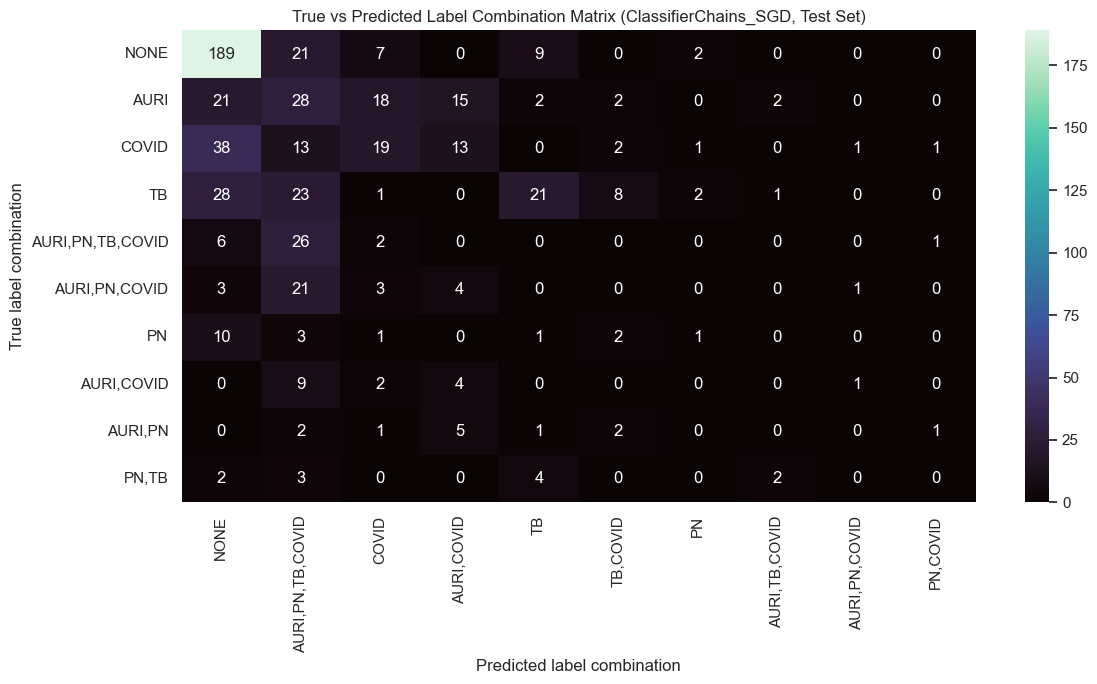

In [15]:
# True-vs-predicted label-combination matrix (best model)
best_model = summary_vis.iloc[0]['model']
pred_path = analysis_dir / f'{best_model}_test_predictions.csv'

if not pred_path.exists():
    raise FileNotFoundError(f'{pred_path} not found.')

pred_df = pd.read_csv(pred_path)

# Keep matrix readable by focusing on most frequent combinations
max_rows = 10
max_cols = 10

top_true = pred_df['true_labels'].value_counts().head(max_rows).index
top_pred = pred_df['pred_labels'].value_counts().head(max_cols).index

transition = pd.crosstab(pred_df['true_labels'], pred_df['pred_labels'])
transition = transition.reindex(index=top_true, columns=top_pred, fill_value=0)

plt.figure(figsize=(12, 7))
sns.heatmap(transition, annot=True, fmt='d', cmap='mako')
plt.title(f'True vs Predicted Label Combination Matrix ({best_model}, Test Set)')
plt.xlabel('Predicted label combination')
plt.ylabel('True label combination')
plt.tight_layout()
plt.show()


## Interactive Prediction Test

Run this cell to input a sentence and classify it with the best-performing model (by test micro-F1).

In [16]:
# Interactive one-sentence prediction using the best model
required_vars = ['X_train', 'y_train', 'X_val', 'y_val', 'word_vec', 'char_vec', 'OUTPUT_DIR']
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        'Missing required variables: ' + ', '.join(missing)
        + '. Run data prep, vectorization, and training cells first.'
    )

if 'summary_df' in globals() and isinstance(summary_df, pd.DataFrame) and not summary_df.empty:
    ranking_df = summary_df.sort_values('test_micro_f1', ascending=False).reset_index(drop=True)
elif 'summary_vis' in globals() and isinstance(summary_vis, pd.DataFrame) and not summary_vis.empty:
    ranking_df = summary_vis.sort_values('test_micro_f1', ascending=False).reset_index(drop=True)
else:
    summary_path = OUTPUT_DIR / 'multilabel_evaluation_summary.csv'
    if not summary_path.exists():
        raise FileNotFoundError(f'{summary_path} not found. Run training/evaluation first.')
    ranking_df = pd.read_csv(summary_path).sort_values('test_micro_f1', ascending=False).reset_index(drop=True)

best_model_name = ranking_df.iloc[0]['model']

if 'best_params_by_model' in globals() and best_model_name in best_params_by_model:
    best_params = best_params_by_model[best_model_name]['best_params']
else:
    params_path = OUTPUT_DIR / f'{best_model_name}_best_params.json'
    if not params_path.exists():
        raise FileNotFoundError(f'{params_path} not found. Run tuning/training first.')
    with open(params_path, 'r', encoding='utf-8') as f:
        best_params = json.load(f)

inference_model = build_model(best_model_name, best_params, seed=SEED)
inference_model.fit(X_train, y_train)

thresholds_path = OUTPUT_DIR / f'{best_model_name}_thresholds.json'
if thresholds_path.exists():
    with open(thresholds_path, 'r', encoding='utf-8') as f:
        thresholds = {k: float(v) for k, v in json.load(f).items()}
else:
    # Fallback: derive thresholds from the current validation split
    val_proba = predict_proba_matrix(inference_model, X_val)
    thresholds = tune_thresholds(y_val, val_proba, LABELS)

# Edit this before each run
user_text = 'May ubo po ako, lagnat, at hirap huminga simula kahapon.'
user_text = user_text.strip()
if not user_text:
    raise ValueError('`user_text` is empty. Set a non-empty sentence before running this cell.')

X_user = hstack([word_vec.transform([user_text]), char_vec.transform([user_text])])
user_proba = predict_proba_matrix(inference_model, X_user)
user_pred = apply_thresholds(user_proba, thresholds, LABELS)[0]

predicted_labels = [label for i, label in enumerate(LABELS) if int(user_pred[i]) == 1]
print(f'Best model used: {best_model_name}')
print('Predicted labels:', ', '.join(predicted_labels) if predicted_labels else 'NONE')

pd.DataFrame(
    {
        'label': LABELS,
        'probability': user_proba[0],
        'threshold': [thresholds[label] for label in LABELS],
        'predicted': user_pred.astype(int),
    }
).sort_values('probability', ascending=False).reset_index(drop=True)


Best model used: ClassifierChains_SGD
Predicted labels: AURI, PN, TB, COVID


,label,probability,threshold,predicted
0,COVID,0.999872,0.18,1
1,AURI,0.999395,0.10,1
2,TB,0.997933,0.18,1
3,PN,0.977548,0.45,1
